In [1]:
# Standard library imports
import os
import random
import sys

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cProfile
import pstats

# Configure matplotlib
plt.style.use('fig.style')
figsize = (8,4)

# Add project root to path
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

# Local imports
from src.get_hg_projection_matrix import get_hg_projection_matrix
from src.matrix_visualizer import visualize_matrix
from src.seq_embedder import SeqEmbedder
from src.get_adjacent_features_upto_order import get_adjacent_features_upto_order

from src import get_additive_model_features, get_pairwise_model_features
from src import get_alphabet

pairwise:
features[:num_to_show]=['****', '***A', '***C', '***G', '***T', '**A*', '**C*', '**G*', '**T*', '*A**']
features[-num_to_show:]=['**G*', '**T*', '*A**', '*C**', '*G**', '*T**', 'A***', 'C***', 'G***', 'T***']



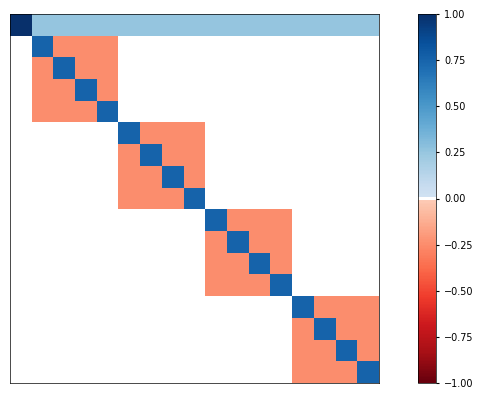

In [2]:
## Additive model

L = 4
alphabet = get_alphabet('dna')
num_to_show = 10
features = get_additive_model_features(L=L, alphabet=alphabet)
print(f'pairwise:\n{features[:num_to_show]=}\n{features[-num_to_show:]=}\n')

P = get_hg_projection_matrix(features=features, alphabet=alphabet, bg_type='uniform', wildcard_char='*', out_type='df')
visualize_matrix(P.values, show_grid=False, figsize=figsize)


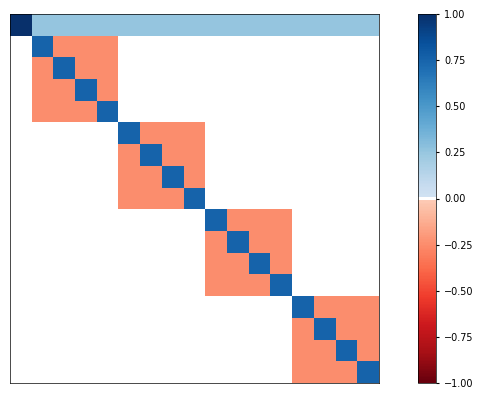

In [3]:
from src.get_additive_zs_projection_matrix import get_additive_zs_projection_matrix
mat = get_additive_zs_projection_matrix(L=L, alphabet=alphabet)
visualize_matrix(mat.todense(), show_grid=False, figsize=figsize)


pairwise:
features[:num_to_show]=['*****', '****A', '****C', '****G', '****T', '***A*', '***C*', '***G*', '***T*', '**A**']
features[-num_to_show:]=['T**G*', 'T**T*', 'T*A**', 'T*C**', 'T*G**', 'T*T**', 'TA***', 'TC***', 'TG***', 'TT***']



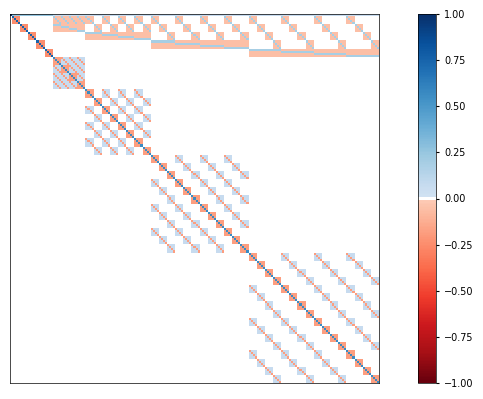

In [4]:
## Pairwise model

L = 5
alphabet = get_alphabet('dna')
num_to_show = 10
features = get_pairwise_model_features(L=L, alphabet=alphabet)
print(f'pairwise:\n{features[:num_to_show]=}\n{features[-num_to_show:]=}\n')

P = get_hg_projection_matrix(features=features, alphabet=alphabet, bg_type='uniform', wildcard_char='*', out_type='df')
visualize_matrix(P.values, show_grid=False, figsize=figsize)

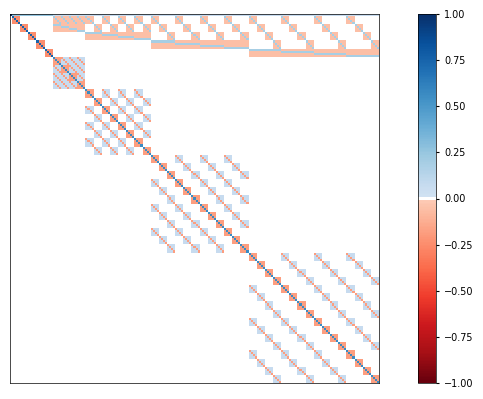

In [5]:
from src.get_pairwise_zs_projection_matrix import get_pairwise_zs_projection_matrix
P = get_pairwise_zs_projection_matrix(L=L, alphabet=alphabet)
visualize_matrix(P.todense(), show_grid=False, figsize=figsize)

In [6]:
import cProfile
import pstats
from pstats import SortKey

L = 5
alphabet = get_alphabet('protein')
features = get_pairwise_model_features(L=L, alphabet=alphabet)

# Profile the hierarchical gauge method
with cProfile.Profile() as pr_slow:
    P_slow = get_hg_projection_matrix(features=features, alphabet=alphabet, bg_type='uniform', wildcard_char='*', out_type='sparse')

# Print hierarchical gauge profiling results
print("Hierarchical gauge method profiling:")
pstats.Stats(pr_slow).strip_dirs().sort_stats('cumulative').print_stats(10)

# Profile the zero-sum method
with cProfile.Profile() as pr_fast:
    P_fast = get_pairwise_zs_projection_matrix(L=L, alphabet=alphabet)

# Print zero-sum profiling results 
print("\nZero-sum method profiling:")
pstats.Stats(pr_fast).strip_dirs().sort_stats('cumulative').print_stats(10)


Hierarchical gauge method profiling:
         3610066 function calls (3610042 primitive calls) in 2.870 seconds

   Ordered by: cumulative time
   List reduced from 243 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.592    0.592    1.047    1.047 get_hg_projection_matrix.py:8(get_hg_projection_matrix)
     4101    0.200    0.000    0.404    0.000 _get_suborbit_features.py:5(_get_suborbit_features)
        1    0.000    0.000    0.312    0.312 _compressed.py:29(__init__)
        1    0.000    0.000    0.265    0.265 _coo.py:30(__init__)
  1766101    0.202    0.000    0.202    0.000 {method 'join' of 'str' objects}
       10    0.182    0.018    0.182    0.018 {built-in method numpy.asarray}
  1766106    0.149    0.000    0.149    0.000 {method 'append' of 'list' objects}
        3    0.122    0.041    0.122    0.041 {built-in method numpy.array}
        3    0.000    0.000    0.101    0.034 _base.py:1369(_get_index_d

In [7]:
# Get encoder; use to encode sequences
embedder = SeqEmbedder(features=features)
N = len(features)

# Check that gauge matches for every sequence
num_thetas = 100
for theta_num in range(num_thetas):
    
    # Choose a random feature vector
    theta = np.random.randn(N)
    
    # Project the feature vector using the two methods
    theta_fixed_slow = P_slow@theta
    theta_fixed_fast = P_fast@theta
    
    # Check that the two functions are close        
    assert np.all(np.isclose(theta_fixed_slow, theta_fixed_fast)), f'{theta_fixed_slow=}\n{theta_fixed_fast=}'
    
print(f'Tested {num_thetas} random feature vectors; all passed.')

Tested 100 random feature vectors; all passed.


In [8]:
# Push limits of the zero-sum method
L = 20
alphabet = get_alphabet('protein')

# Profile the zero-sum method
with cProfile.Profile() as pr_fast:
    P_fast = get_pairwise_zs_projection_matrix(L=L, alphabet=alphabet)

# Print zero-sum profiling results 
print(f"\nZero-sum method:")
pstats.Stats(pr_fast).strip_dirs().sort_stats('cumulative').print_stats(10)

print(f"N = {P_fast.shape[0]:,}")
print(f"number of non-zero elements = {P_fast.nnz:,}")
print(f"density = {P_fast.nnz / P_fast.shape[0]**2:.2%}")

# Get memory usage of sparse matrix using built-in methods
data_bytes = P_fast.data.nbytes
indices_bytes = P_fast.indices.nbytes
indptr_bytes = P_fast.indptr.nbytes
total_bytes = data_bytes + indices_bytes + indptr_bytes

print(f"\nMemory usage breakdown:")
print(f"Data array: {data_bytes:,} bytes")
print(f"Indices array: {indices_bytes:,} bytes") 
print(f"Index pointer array: {indptr_bytes:,} bytes")
print(f"Total: {total_bytes:,} bytes")


Zero-sum method:
         7502425 function calls (7502417 primitive calls) in 6.649 seconds

   Ordered by: cumulative time
   List reduced from 238 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        4    0.000    0.000    6.773    1.693 base_events.py:1915(_run_once)
      4/3    0.035    0.009    6.649    2.216 selectors.py:558(select)
        1    0.871    0.871    6.648    6.648 get_pairwise_zs_projection_matrix.py:26(get_pairwise_zs_projection_matrix)
    79842    0.095    0.000    5.316    0.000 _lil.py:267(__setitem__)
    79842    0.284    0.000    5.185    0.000 _index.py:124(__setitem__)
    79842    3.016    0.000    3.266    0.000 _lil.py:255(_set_arrayXarray)
    79842    0.094    0.000    0.936    0.000 _index.py:10(_broadcast_arrays)
    79842    0.109    0.000    0.836    0.000 _stride_tricks_impl.py:495(broadcast_arrays)
   159682    0.434    0.000    0.636    0.000 _stride_tricks_impl.py:350(_broadcast_to)
 

In [9]:
# Wow. Even as a sparse matrix the projection matrix is huge. 
# There must be a faster way to do this.
# Oh, least squares optimization might be fastest. 
# Or if we just go parameter by parameter, that might work. Especially for the pairwise model
# Think about how to do this on the train.